In [1]:
# Numerical & data handling
import numpy as np
import pandas as pd
import math

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import LabelEncoder, PowerTransformer, StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Specialized packages
from ISLP import confusion_table

# Function

In [2]:
def preprocess_split(X, y, train_years=(2014,2022), test_years=(2023,2024)):
    
    # Extract year from index
    years = pd.Series(X.index.astype(str).str[-4:].astype(int), index=X.index)
    train_mask = years.between(*train_years)
    test_mask  = years.between(*test_years)
    
    # Split data
    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    
    # Pipeline with median imputation, Yeo-Johnson transform, and scaling
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('yeojohnson', PowerTransformer(method='yeo-johnson')),
        ('standard', StandardScaler())
    ])
    
    # Fit on train, transform both train and test
    X_tr_sc = pipeline.fit_transform(X_train)
    X_ts_sc = pipeline.transform(X_test)
    
    # Convert back to DataFrame with same columns and index
    X_tr_sc = pd.DataFrame(X_tr_sc, columns=X_train.columns, index=X_train.index)
    X_ts_sc = pd.DataFrame(X_ts_sc, columns=X_test.columns, index=X_test.index)
    
    return X_train, X_test, y_train, y_test, X_tr_sc, X_ts_sc, pipeline


In [11]:
def feature_selection_and_report(estimator, X_train, y_train, X_test, y_test,
                                 n_features=20, cv=5, direction="forward"):
    """
    Perform sequential feature selection, fit the estimator, 
    and print classification metrics.
    """
    # Feature selection
    sfs = SequentialFeatureSelector(
        estimator,
        direction=direction,              # "forward" or "backward"
        n_features_to_select=n_features,  # int or float
        cv=cv
    )
    sfs.fit(X_train, y_train)
    selected_features = X_test.columns[sfs.get_support()]
    
    # Train model on selected features
    estimator.fit(X_train[selected_features], y_train)
    
    # Predict on test set using same selected features
    y_pred = estimator.predict(X_test[selected_features])
    
    # Metrics
    ct = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    cr_dict = classification_report(y_test, y_pred, output_dict= True)

    
    return selected_features, ct, cr, cr_dict

In [18]:
def summarize_reports(report_list, model_names=None):
    """
    Takes a list of classification_report dictionaries and returns a summary DataFrame
    with accuracy, weighted precision, recall, and F1-score.

    Parameters:
    - report_list: list of dicts from classification_report(..., output_dict=True)
    - model_names: optional list of model names (same length as report_list)

    Returns:
    - pd.DataFrame with summary metrics
    """
    summary = []
    for i, report in enumerate(report_list):
        name = model_names[i] if model_names else f"Model_{i+1}"
        summary.append({
            "Model": name,
            "Accuracy": report.get("accuracy", None),
            "Weighted Precision": report["weighted avg"]["precision"],
            "Weighted Recall": report["weighted avg"]["recall"],
            "Weighted F1": report["weighted avg"]["f1-score"]
        })
    df = pd.DataFrame(summary)
    pd.set_option("display.max_columns", None)  # ensures all columns are shown
    pd.set_option("display.width", 1000)        # sets wide enough console width
    return df

In [4]:
def plot_pairplot(df, hue=None):

    if hue is not None:
        df_plot = df.copy()
        df_plot['__hue__'] = hue  # temporary column
        return sns.pairplot(df_plot, hue='__hue__')
    else:
        return sns.pairplot(df)

In [5]:
def plot_heatmap(df, title = None, method='pearson', cmap='coolwarm', annot=True, figsize=(12,10)):
    corr = df.corr(method=method)
    plt.figure(figsize=figsize)
    sns.heatmap(corr, cmap=cmap, annot=annot, fmt=".2f", center=0,
                square=True, linewidths=0.5, linecolor='white',
                cbar_kws={"shrink": 0.8})
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    if title is None:
        plt.title(f"{method.capitalize()} Correlation Heatmap", fontsize=14)
    else:
        plt.title(title, fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Benchmark model (multinomial regression model) results

In [6]:
# Import dataset
tej = pd.read_csv("tej.csv", index_col = 0)

# Replace '-' with NaN
tej.replace('-', np.nan, inplace=True)

# Drop rows where the target column (last column) == "C"
tej_filtered = tej[tej.iloc[:, -1] != "C"]

# Split into X and y
X = tej_filtered.iloc[:, :-1]
y = tej_filtered.iloc[:, -1]

In [7]:
# Splitting the dataset into training set and testing set.

X_train, X_test, y_train, y_test, X_tr_sc, X_ts_sc, pipeline = preprocess_split(X, y)

## Multinomial logistic regression using all the predictors.

In [8]:
model_all = LogisticRegression(penalty= 'l2', solver= 'saga', max_iter= 10000)
results_all = model_all.fit(X_tr_sc,y_train)
y_pred_all = results_all.predict(X_ts_sc)

ct_all = confusion_table(y_pred_all, y_test)
cr_all = classification_report(y_test, y_pred_all)
print(ct_all)
print(cr_all)

Truth        5    6    7   8   9  D
Predicted                          
5          258  130   21   4   1  0
6           76  214   78  14   1  0
7            8   59  113  59  10  0
8            1    5   26  36  11  0
9            2    0    1  19  29  5
D            0    0    0   0   2  0
              precision    recall  f1-score   support

           5       0.62      0.75      0.68       345
           6       0.56      0.52      0.54       408
           7       0.45      0.47      0.46       239
           8       0.46      0.27      0.34       132
           9       0.52      0.54      0.53        54
           D       0.00      0.00      0.00         5

    accuracy                           0.55      1183
   macro avg       0.43      0.43      0.43      1183
weighted avg       0.54      0.55      0.54      1183



## Multinomial logistic regression using selected features

### Finding 10 best predictors using forward stepwise feature selection method

In [12]:
selected_featuresfw10, ct_fw10, cr_fw10, cr_dictfw10 = feature_selection_and_report(estimator = LogisticRegression(max_iter = 20000), 
                             X_train = X_tr_sc,
                             y_train = y_train, 
                             X_test = X_ts_sc, 
                             y_test = y_test, 
                             n_features= 10,
                             direction= "forward"
                             )
print("Confusion Matrix: \n",ct_fw10)
print("\nClassification report: \n", cr_fw10)

Confusion Matrix: 
 [[234  94  17   0   0   0]
 [115 208  84   1   0   0]
 [ 22  87 112  17   1   0]
 [  7  22  63  27  13   0]
 [  2   3  12  15  22   0]
 [  0   0   0   0   5   0]]

Classification report: 
               precision    recall  f1-score   support

           5       0.62      0.68      0.65       345
           6       0.50      0.51      0.51       408
           7       0.39      0.47      0.43       239
           8       0.45      0.20      0.28       132
           9       0.54      0.41      0.46        54
           D       0.00      0.00      0.00         5

    accuracy                           0.51      1183
   macro avg       0.42      0.38      0.39      1183
weighted avg       0.51      0.51      0.50      1183



c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

### Finding 20 best predictors using forward stepwise feature selection method

In [14]:
selected_featuresfw20, ct_fw20, cr_fw20, cr_dictfw20 = feature_selection_and_report(estimator = LogisticRegression(max_iter = 20000), 
                             X_train = X_tr_sc,
                             y_train = y_train, 
                             X_test = X_ts_sc, 
                             y_test = y_test, 
                             n_features= 20,
                             direction= "forward"
                             )
print("Confusion Matrix: \n",ct_fw20)
print("\nClassification report: \n", cr_fw20)

Confusion Matrix: 
 [[239  93  12   0   0   1]
 [112 209  84   3   0   0]
 [ 23  81 111  22   2   0]
 [  7  25  58  29  13   0]
 [  1   2  15  13  22   1]
 [  0   0   0   0   5   0]]

Classification report: 
               precision    recall  f1-score   support

           5       0.63      0.69      0.66       345
           6       0.51      0.51      0.51       408
           7       0.40      0.46      0.43       239
           8       0.43      0.22      0.29       132
           9       0.52      0.41      0.46        54
           D       0.00      0.00      0.00         5

    accuracy                           0.52      1183
   macro avg       0.41      0.38      0.39      1183
weighted avg       0.51      0.52      0.51      1183



### Finding best predictors using forward stepwise feature selection method automatically

In [20]:
selected_featuresfwbest, ct_fwbest, cr_fwbest, cr_dictfwbest = feature_selection_and_report(estimator = LogisticRegression(max_iter = 20000), 
                             X_train = X_tr_sc,
                             y_train = y_train, 
                             X_test = X_ts_sc, 
                             y_test = y_test, 
                             n_features= 'auto',
                             direction= "forward"
                             )
print("Confusion Matrix: \n",ct_fwbest)
print("\nClassification report: \n", cr_fwbest)

Confusion Matrix: 
 [[240  90  14   0   0   1]
 [116 206  83   3   0   0]
 [ 22  78 117  20   2   0]
 [  7  23  59  28  15   0]
 [  1   2  14  14  22   1]
 [  0   0   0   0   5   0]]

Classification report: 
               precision    recall  f1-score   support

           5       0.62      0.70      0.66       345
           6       0.52      0.50      0.51       408
           7       0.41      0.49      0.44       239
           8       0.43      0.21      0.28       132
           9       0.50      0.41      0.45        54
           D       0.00      0.00      0.00         5

    accuracy                           0.52      1183
   macro avg       0.41      0.38      0.39      1183
weighted avg       0.51      0.52      0.51      1183



In [21]:
selected_featuresfwbest

Index(['current liabilities', 'common shares', 'share capital', 'total capital', 'retained earnings', 'total shareholder's equity', 'operating income', 'r&d expense', 'expected credit impairment (loss) profit - operating expense', 'net income before interest and tax', 'cash flow from operations', 'cash flow from investing activities', 'cash flow from financing activities', 'long-term and short-term borrowings', 'net liabilities', 'financial leverage', 'operating leverage', 'interest coverage ratio', 'cash flow adequacy ratio', 'interest expense ratio', 'interest expense ratio (B)', 'total liabilities/total net worth', 'operating profit/paid-in capital ratio', 'pre-tax net profit/paid-in capital ratio'], dtype='object')

### Finding 10 best predictors using backward stepwise feature selection method

In [22]:
selected_featuresbw10, ct_bw10, cr_bw10, cr_dictbw10 = feature_selection_and_report(estimator = LogisticRegression(max_iter = 20000), 
                             X_train = X_tr_sc,
                             y_train = y_train, 
                             X_test = X_ts_sc, 
                             y_test = y_test, 
                             n_features= 10,
                             direction= "backward"
                             )
print("Confusion Matrix: \n",ct_bw10)
print("\nClassification report: \n", cr_bw10)

Confusion Matrix: 
 [[243  86  15   1   0   0]
 [118 225  63   2   0   0]
 [ 25  79 115  18   2   0]
 [  4  23  57  33  15   0]
 [  1   2  10  12  29   0]
 [  0   0   0   0   5   0]]

Classification report: 
               precision    recall  f1-score   support

           5       0.62      0.70      0.66       345
           6       0.54      0.55      0.55       408
           7       0.44      0.48      0.46       239
           8       0.50      0.25      0.33       132
           9       0.57      0.54      0.55        54
           D       0.00      0.00      0.00         5

    accuracy                           0.55      1183
   macro avg       0.45      0.42      0.43      1183
weighted avg       0.54      0.55      0.54      1183



c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [23]:
selected_featuresbw10

Index(['total liabilities', 'share capital', 'total capital', 'finance costs', 'current ratio', 'quick ratio', 'interest expense ratio (B)', 'total liabilities/total net worth', 'operating profit/paid-in capital ratio', 'retention ratio'], dtype='object')

### Finding 20 best predictors using backward stepwise feature selection method

In [24]:
selected_featuresbw20, ct_bw20, cr_bw20, cr_dictbw20 = feature_selection_and_report(estimator = LogisticRegression(max_iter = 20000), 
                             X_train = X_tr_sc,
                             y_train = y_train, 
                             X_test = X_ts_sc, 
                             y_test = y_test, 
                             n_features= 20,
                             direction= "backward"
                             )
print("Confusion Matrix: \n",ct_bw20)
print("\nClassification report: \n", cr_bw20)

Confusion Matrix: 
 [[248  86  11   0   0   0]
 [125 218  63   2   0   0]
 [ 27  69 117  26   0   0]
 [  4  21  60  29  18   0]
 [  2   1   9  11  31   0]
 [  0   0   0   0   5   0]]

Classification report: 
               precision    recall  f1-score   support

           5       0.61      0.72      0.66       345
           6       0.55      0.53      0.54       408
           7       0.45      0.49      0.47       239
           8       0.43      0.22      0.29       132
           9       0.57      0.57      0.57        54
           D       0.00      0.00      0.00         5

    accuracy                           0.54      1183
   macro avg       0.44      0.42      0.42      1183
weighted avg       0.53      0.54      0.53      1183



c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

### Finding best predictors using backward stepwise feature selection method automatically

In [25]:
selected_featuresbwbest, ct_bwbest, cr_bwbest, cr_dictbwbest = feature_selection_and_report(estimator = LogisticRegression(max_iter = 20000), 
                             X_train = X_tr_sc,
                             y_train = y_train, 
                             X_test = X_ts_sc, 
                             y_test = y_test, 
                             n_features= 'auto',
                             direction= "backward"
                             )
print("Confusion Matrix: \n",ct_bwbest)
print("\nClassification report: \n", cr_bwbest)

Confusion Matrix: 
 [[253  76  16   0   0   0]
 [133 207  66   2   0   0]
 [ 26  63 124  25   1   0]
 [  3  19  61  31  18   0]
 [  1   3   9  11  29   1]
 [  0   0   0   0   5   0]]

Classification report: 
               precision    recall  f1-score   support

           5       0.61      0.73      0.66       345
           6       0.56      0.51      0.53       408
           7       0.45      0.52      0.48       239
           8       0.45      0.23      0.31       132
           9       0.55      0.54      0.54        54
           D       0.00      0.00      0.00         5

    accuracy                           0.54      1183
   macro avg       0.44      0.42      0.42      1183
weighted avg       0.54      0.54      0.53      1183



In [26]:
selected_featuresbwbest

Index(['total assets', 'total liabilities', 'share capital', 'total capital', 'retained earnings', 'working capital', 'operating profit', 'finance costs', 'cash flow from investing activities', 'cash flow from financing activities', 'net liabilities', 'Tobins Q', 'roa - comprehensive income', 'roe - comprehensive income', 'cash flow adequacy ratio', 'cash reinvestment ratio', 'current ratio', 'quick ratio', 'interest expense ratio (B)', 'total liabilities/total net worth', 'debt ratio', 'long-term funding ratio (A)', 'operating profit/paid-in capital ratio', 'retention ratio'], dtype='object')

In [27]:
selected_featuresfw10lasso, ct_fw10lasso, cr_fw10lasso = feature_selection_and_report(estimator = LogisticRegression(max_iter = 100000, penalty='l1', solver= 'saga'), 
                             X_train = X_tr_sc,
                             y_train = y_train, 
                             X_test = X_ts_sc, 
                             y_test = y_test, 
                             n_features= 10,
                             direction= "forward"
                             )
print("Confusion Matrix: \n",ct_fw10lasso)
print("\nClassification report: \n", cr_fw10lasso)

c:\Users\NITRO 5\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


KeyboardInterrupt: 

In [28]:
# Assume you have a list of report dicts
reports = [cr_dictfw10, cr_dictfw20, cr_dictfwbest, cr_dictbw10, cr_dictbw20, cr_dictbwbest]  # each from output_dict=True
names = ['MLR: Forward 10 preds', 'MLR: Forward 20 preds', 'MLR: Forward auto', 'MLR: Backward 10 preds', 'MLR: Backward 20 preds', 'MLR: Backward auto']
""
summary_df = summarize_reports(reports, model_names=names)
print(summary_df)


                    Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1
0   MLR: Forward 10 preds  0.509721            0.506131         0.509721     0.501189
1   MLR: Forward 20 preds  0.515638            0.510564         0.515638     0.507844
2       MLR: Forward auto  0.518174            0.512636         0.518174     0.509660
3  MLR: Backward 10 preds  0.545224            0.539336         0.545224     0.536676
4  MLR: Backward 20 preds  0.543533            0.533185         0.543533     0.533171
5      MLR: Backward auto  0.544379            0.537234         0.544379     0.534357


Based on the results, we are going to select the 10 predictors we got from using backward stepwise feature selection method.

# EDA for selected features

In [ ]:
# Impute or drop missing values
imputer = SimpleImputer(missing_values = np.nan, strategy = 'median')
imputer.fit(X)
X_df = imputer.transform(X)

le = LabelEncoder()
y = le.fit_transform(y)

X_df = pd.DataFrame(X_df, columns = X.columns, index = X.index)

In [ ]:
desc_stats10 = X_df[selected_featuresbw10].describe().T
desc_stats10['skewness'] = X_df[selected_featuresbw10].skew()
desc_stats10['kurtosis'] = X_df[selected_featuresbw10].kurtosis()
desc_stats10

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
total liabilities,6622.0,1.155298e+07,6.238202e+07,4946.00,944673.7500,2295347.000,5.886414e+06,1.607622e+09,15.823604,307.616960
share capital,6622.0,3.400313e+06,7.710777e+06,157600.00,875460.0000,1490550.000,3.005579e+06,1.055962e+08,7.848712,78.688624
total capital,6622.0,1.191068e+06,5.305519e+06,-207088.00,59116.2500,305537.500,8.798752e+05,1.059197e+08,14.133891,236.683715
finance costs,6622.0,1.095326e+05,4.448219e+05,0.00,4889.2500,18172.500,5.762400e+04,9.556030e+06,10.996830,157.610583
current ratio,6622.0,3.593196e+02,1.518876e+03,5.88,135.6825,183.705,2.854175e+02,7.114948e+04,27.089707,973.154695
quick ratio,6622.0,2.385410e+02,7.891300e+02,0.43,68.2750,114.365,1.975925e+02,1.874478e+04,14.625827,262.141099
interest expense ratio (B),6622.0,3.671599e+00,7.724819e+01,0.00,0.1600,0.560,1.360000e+00,5.851140e+03,67.099928,4980.850510
total liabilities/total net worth,6622.0,1.208301e+02,5.430664e+02,0.48,42.7750,80.315,1.342325e+02,4.164892e+04,68.019548,5168.924813
operating profit/paid-in capital ratio,6622.0,1.717046e+01,4.067429e+01,-777.80,-1.2100,9.090,2.801250e+01,6.319900e+02,2.509268,58.179988
retention ratio,6622.0,1.541714e+01,7.767598e+02,-59557.14,21.8550,37.285,5.418750e+01,1.000000e+02,-69.230268,5240.149698


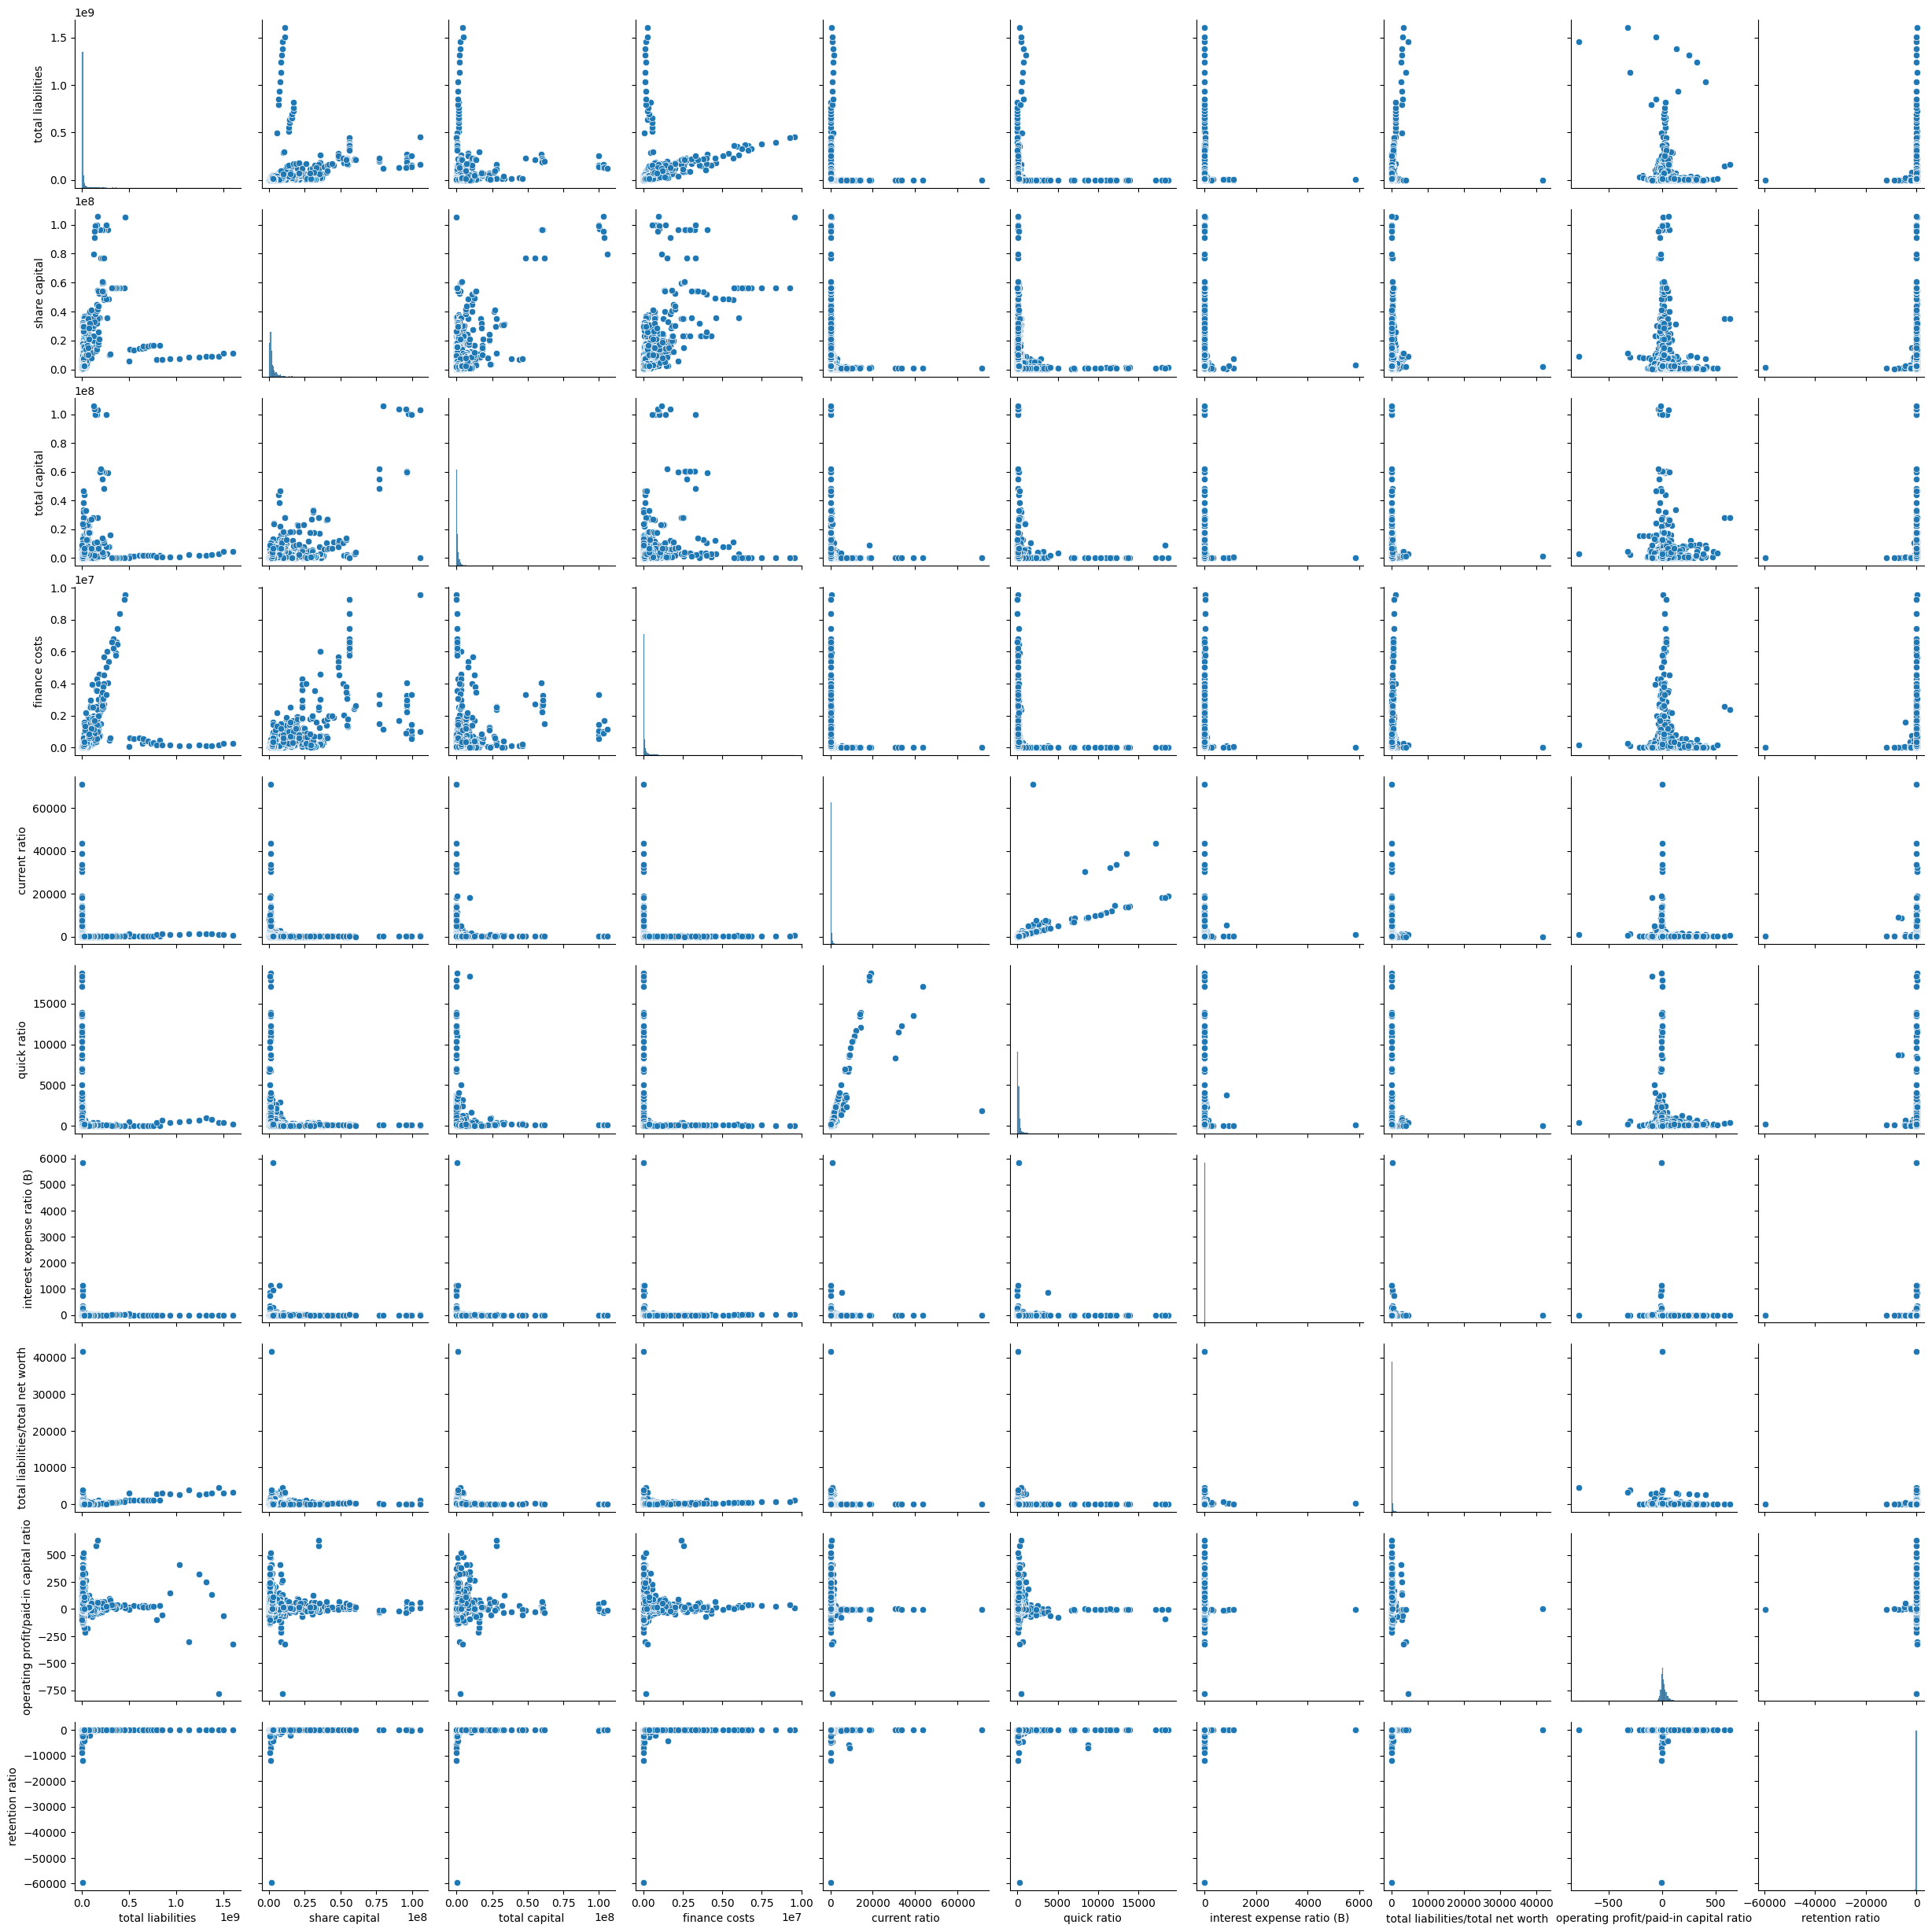

In [ ]:
plot_pairplot(df = X_df[selected_featuresbw10])

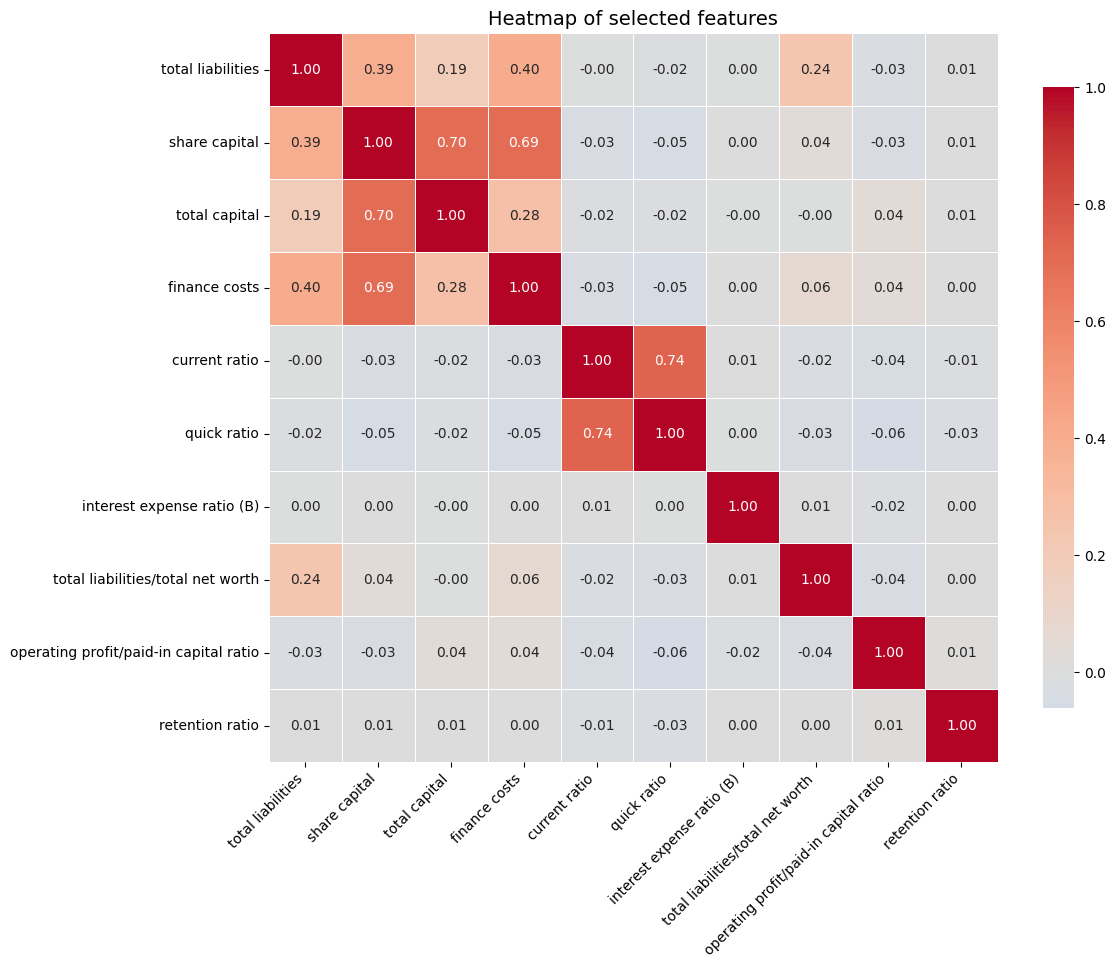

In [ ]:
plot_heatmap(df = X_df[selected_featuresbw10], title= 'Heatmap of selected features')